# Lidar–VectorNav Sync Workbench

This notebook starts the implementation of per-window timing-offset estimation for lidar vertical stares against continuous VectorNav `VelNED2`.

The initial implementation covers:

- project setup and shared imports
- cached lidar chunk/file bookkeeping
- periodic beam buffers and single-file reads
- chunk extraction with the existing `fit_offset` prior
- mdv-based sync signal construction using the `1.03` intensity threshold
- FFT bandpass filtering, analytic-envelope construction, and FFT cross-correlation
- one-window diagnostics for coarse and fine timing estimates

Later cells can extend this to multi-window continuity priors, jump detection, and production integration.

In [33]:
# preamble
using Revise
using Pkg; Pkg.activate(".")

using Dates
using Printf
using Statistics
using FFTW
# using PyPlot
using PythonPlot
using NCDatasets

includet("./lidar_vn_sync.jl")
using .LidarVNSync

ctx = LidarVNSync.setup_sync_context()
Env = ctx.Env
Vn = ctx.Vn
UV = ctx.UV
beams = ctx.beams
icvn = ctx.icvn
nz = ctx.nz

  Activating project at `~/Projects/lidar/ASTRAL2024`


80

In [34]:
# utility functions extend Py[thon]Plot

# Methods for PyPlot or PythonPlot handle missing by wrapping in np.ma masked arrays.
if @isdefined(PythonPlot)
	using PythonCall
	"Convert Julia Arrays with missing to Python masked arrays (no recursion)."
	function julia_to_masked(a::AbstractArray{<:Union{Missing, Float64, Int, Real}})
		np = PythonCall.pyimport("numpy")
		return np.ma.masked_invalid(np.array(replace(a, missing => NaN)))
	end
	function julia_to_masked(a)
		return a
	end

	# Overload plot to auto-convert arrays with missings
	import PythonPlot: plot
	function plot(x::AbstractArray{<:Union{Missing, Float64, Int, Real}}, y::AbstractArray{<:Union{Missing, Float64, Int, Real}}, args...; kwargs...)
		plot(julia_to_masked(x), julia_to_masked(y), args...; kwargs...)
	end
	function plot(x::AbstractArray{<:Union{Missing, Float64, Int, Real}}, args...; kwargs...)
		plot(julia_to_masked(x), args...; kwargs...)
	end

	"close plots with close(\"all\")"
	close(s::String) = PythonCall.pyimport("matplotlib.pyplot").close(s)
elseif @isdefined(PyPlot)
	using PyCall
	using PyCall: PyObject
	# allow for plotting with missing values
	function PyCall.PyObject(a::Array{Union{T,Missing},N}) where {T,N}
		numpy_ma = PyCall.pyimport("numpy").ma
		pycall(numpy_ma.array, Any, coalesce.(a,zero(T)), mask=ismissing.(a))
	end
end

# "convert arrays with missings to masked python float64 arrays"
# msk(y) = ma.masked_invalid(np.array(replace(y, missing => NaN), dtype="float64"))


"plotf(f, x, args...)  function plot wrapper"
plotf(f, x, args...) = plot(x, f.(x), args...)

plotf

In [35]:
# notebook workflow functions

function process_lidar_vn_data(; mode=:test, test_ic=175:190, ntop=nz,
    reset_prior_on_file_boundary=false, reset_prior_on_rejected_sync=false,
    nc_dir="./data/netcdf_stare")
    ic_list = mode == :all ? collect(icvn) : collect(test_ic)
    # UV is passed through the shared reader for compatibility and later motion correction.
    # The sync offsets computed here are fit only from mdv and vn2.
    result = LidarVNSync.process_sync_data(
        beams,
        Env,
        Vn,
        UV,
        ic_list;
        ntop=ntop,
        reset_prior_on_file_boundary=reset_prior_on_file_boundary,
        reset_prior_on_rejected_sync=reset_prior_on_rejected_sync,
        nc_dir=nc_dir,
    )
    return result
end

function save_sync_data_netcdf(result; nc_out=joinpath("epsilon_data", "vn_sync_offsets.nc"))
    return LidarVNSync.save_sync_netcdf(result; nc_out=nc_out)
end

function run_sync_diagnostics(result; mode=:test, single_ic=nothing, ntop=nz)
    fig_offsets = LidarVNSync.diagnostic_offsets(result)

    fig_single = nothing
    if mode == :test
        ic = isnothing(single_ic) ? result.seq_ic[1] : single_ic
        single = LidarVNSync.diagnostic_single_window(beams, Env, Vn, UV, ic; ntop=ntop)
        fig_single = single.fig
    end

    return (; fig_offsets, fig_single)
end

# wrapper functions for LidarVNSync.jl functions
read_synced_motion_data(nc_path=joinpath("epsilon_data", "vn_sync_offsets.nc")) =
    LidarVNSync.read_synced_motion(nc_path)

motion_correct_stare(dopplervel, nc_path=joinpath("epsilon_data", "vn_sync_offsets.nc"); record_inds=:) =
    LidarVNSync.read_and_motion_correct_stare(dopplervel, nc_path; record_inds=record_inds)


motion_correct_stare (generic function with 2 methods)

In [36]:
# spectral coherence functions for diagnostics

function pearson_finite(x, y)
    xv, yv, _ = LidarVNSync.finite_overlap(Float64.(x), Float64.(y))
    n = length(xv)
    n < 4 && return NaN
    sx = std(xv)
    sy = std(yv)
    (!isfinite(sx) || !isfinite(sy) || sx == 0 || sy == 0) && return NaN
    return cor(xv, yv)
end

function band_coherence_welch_5_20s(x, y; dt=1.0, flo=1 / 20, fhi=1 / 5)
    xv, yv, _ = LidarVNSync.finite_overlap(Float64.(x), Float64.(y))
    n = length(xv)
    n < 48 && return NaN

    nseg = min(128, n)
    nseg < 32 && return NaN
    step = max(8, nseg ÷ 2)

    win = 0.5 .- 0.5 .* cos.(2pi .* (0:(nseg - 1)) ./ (nseg - 1))

    nfreq = div(nseg, 2) + 1
    Sxx = zeros(Float64, nfreq)
    Syy = zeros(Float64, nfreq)
    Sxy = zeros(ComplexF64, nfreq)
    k = 0

    for i0 in 1:step:(n - nseg + 1)
        xs = xv[i0:(i0 + nseg - 1)]
        ys = yv[i0:(i0 + nseg - 1)]

        xs .-= mean(xs)
        ys .-= mean(ys)

        X = FFTW.rfft(xs .* win)
        Y = FFTW.rfft(ys .* win)

        Sxx .+= abs2.(X)
        Syy .+= abs2.(Y)
        Sxy .+= X .* conj.(Y)
        k += 1
    end

    k == 0 && return NaN
    Sxx ./= k
    Syy ./= k
    Sxy ./= k

    coh = abs2.(Sxy) ./ (Sxx .* Syy .+ eps())
    fs = 1 / dt
    freq = collect(0:div(nseg, 2)) .* (fs / nseg)
    band = (freq .>= flo) .& (freq .<= fhi)
    any(band) || return NaN

    c = coh[band]
    c = c[isfinite.(c)]
    isempty(c) && return NaN
    return mean(c)
end

function contiguous_ranges(mask::AbstractVector{Bool}, labels::AbstractVector)
    ranges = Tuple{eltype(labels), eltype(labels)}[]
    i = 1
    n = length(mask)
    while i <= n
        if !mask[i]
            i += 1
            continue
        end
        i0 = i
        while i <= n && mask[i]
            i += 1
        end
        i1 = i - 1
        push!(ranges, (labels[i0], labels[i1]))
    end
    return ranges
end

contiguous_ranges (generic function with 1 method)

In [37]:
# Compare prior reset modes on the same chunk set
# This helps diagnose prior poisoning when offsets get stuck near a bad value.

function compare_prior_reset_modes(; test_chunks=200:20:300, ntop=nz)
    modes = [
        (name="carry", reset_prior_on_file_boundary=false, reset_prior_on_rejected_sync=false),
        (name="file_boundary", reset_prior_on_file_boundary=true, reset_prior_on_rejected_sync=false),
        (name="rejected_sync", reset_prior_on_file_boundary=false, reset_prior_on_rejected_sync=true),
        (name="both", reset_prior_on_file_boundary=true, reset_prior_on_rejected_sync=true),
    ]

    println("mode,chunk,offset_s,corr_sync,coherency_5_20s,is_synced,is_failed")

    for m in modes
        res = process_lidar_vn_data(
            ;
            mode=:test,
            test_ic=test_chunks,
            ntop=ntop,
            reset_prior_on_file_boundary=m.reset_prior_on_file_boundary,
            reset_prior_on_rejected_sync=m.reset_prior_on_rejected_sync,
        )

        seq_ic = res.seq_ic
        offset_s = Float64.(res.seq_final_native)
        valid = isfinite.(offset_s) .& (offset_s .!= LidarVNSync.OFFSET_SENTINEL_S)

        corr_sync = fill(NaN, length(seq_ic))
        coherency_5_20s = fill(NaN, length(seq_ic))

        state_metrics = LidarVNSync.init_stream_state()
        for i in eachindex(seq_ic)
            valid[i] || continue
            ic = seq_ic[i]
            t_shift = offset_s[i]

            win = LidarVNSync.extract_sync_window(beams, Env, state_metrics, Vn, UV, ic; ntop=ntop, nc_dir="./data/netcdf_stare")
            dt1 = LidarVNSync.dt_seconds(win.stare_dt)
            (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)

            vn2_sync = LidarVNSync.shift_signal_linear(win.vn2_xcorr, t_shift; dt=dt1)
            corr_sync[i] = pearson_finite(win.mdv, vn2_sync)
            coherency_5_20s[i] = band_coherence_welch_5_20s(win.mdv, vn2_sync; dt=dt1)
        end

        is_synced = valid .& (corr_sync .>= 0.75) .& (coherency_5_20s .>= 0.95)
        is_failed = valid .& (corr_sync .< 0.05) .& (coherency_5_20s .< 0.15)

        for i in eachindex(seq_ic)
            println("$(m.name),$(seq_ic[i]),$(offset_s[i]),$(corr_sync[i]),$(coherency_5_20s[i]),$(is_synced[i]),$(is_failed[i])")
        end

        valid_corr = corr_sync[valid .& isfinite.(corr_sync)]
        valid_coh = coherency_5_20s[valid .& isfinite.(coherency_5_20s)]
        med_corr = isempty(valid_corr) ? NaN : median(valid_corr)
        med_coh = isempty(valid_coh) ? NaN : median(valid_coh)

        println("SUMMARY,$(m.name),valid=$(count(valid))/$(length(valid)),synced=$(count(is_synced)),failed=$(count(is_failed)),median_corr=$(med_corr),median_coh=$(med_coh)")
    end

    nothing
end

# compare_prior_reset_modes(; test_chunks=200:20:300, ntop=nz)

compare_prior_reset_modes (generic function with 1 method)

In [38]:
# SIGN CONVENTION VALIDATION
# Verify that the corrected sign in offset_base_1hz is working:
# 1. 20 Hz residuals should be small (±0.5 s range, not hitting ±0.6 s boundary)
# 2. Final offsets (s1 + residual_20hz) should be close to brute-force grid-search best shifts
# 3. Correlations should improve after 20 Hz refinement

function pearson_finite_sign_validation(x, y)
    xv, yv, _ = LidarVNSync.finite_overlap(Float64.(x), Float64.(y))
    length(xv) < 4 && return NaN
    sx = std(xv)
    sy = std(yv)
    (!isfinite(sx) || !isfinite(sy) || sx == 0 || sy == 0) && return NaN
    cor(xv, yv)
end

function brute_force_grid_search(mdv, vn2; dt=1.02, lo=-6.0, hi=6.0, step=0.02)
    shifts = collect(lo:step:hi)
    best_shift = NaN
    best_corr = -Inf
    for s in shifts
        vn_shifted = LidarVNSync.shift_signal_linear(vn2, s; dt=dt)
        c = pearson_finite_sign_validation(mdv, vn_shifted)
        if isfinite(c) && c > best_corr
            best_corr = c
            best_shift = s
        end
    end
    return best_shift, best_corr
end

#= slow
validate_ics = [220, 240, 260, 265, 280]
state_validate = LidarVNSync.init_stream_state()
res_validate = LidarVNSync.process_sync_data(beams, Env, Vn, UV, collect(220:280); ntop=nz)
prior_by_ic_validate = Dict(r.ic => r.prior_offset for r in res_validate.seq_results)

println("\n=== SIGN CONVENTION VALIDATION ===")
println("ic,s1_final_s,resid_20hz_s,final_s,brute_best_s,error_s,corr_before,corr_after,residual_in_bounds")
all_good = true
for ic in validate_ics
    w = LidarVNSync.extract_sync_window(beams, Env, state_validate, Vn, UV, ic; ntop=nz, nc_dir="./data/netcdf_stare")
    dt1 = LidarVNSync.dt_seconds(w.stare_dt)
    (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)
    
    prior_s = get(prior_by_ic_validate, ic, 0.0)
    s1 = LidarVNSync.coarse_and_fine_lag(w.mdv, w.vn2_xcorr; prior_seconds=prior_s)
    
    # Correlation before 20 Hz refinement
    vn_1hz = LidarVNSync.shift_signal_linear(w.vn2_xcorr, s1.final_offset; dt=dt1)
    corr_before = pearson_finite_sign_validation(w.mdv, vn_1hz)
    
    # Apply 20 Hz refinement
    rf = LidarVNSync.refine_offset_20hz(w, s1, Vn)
    corr_after = pearson_finite_sign_validation(w.mdv, rf.vn2_1s_aligned)
    
    final_s = s1.final_offset + rf.final_offset_native
    
    # Brute-force grid search
    brute_s, brute_c = brute_force_grid_search(w.mdv, w.vn2_xcorr; dt=dt1, lo=-6, hi=6, step=0.02)
    error_s = abs(final_s - brute_s)
    
    # Check: residual in bounds
    resid_in_bounds = abs(rf.final_offset_native) <= 0.55  # well within ±0.6 search window
    all_good = all_good && resid_in_bounds && error_s < 0.15
    
    println("$(ic),$(round(s1.final_offset; digits=3)),$(round(rf.final_offset_native; digits=3)),$(round(final_s; digits=3)),$(round(brute_s; digits=3)),$(round(error_s; digits=3)),$(round(corr_before; digits=3)),$(round(corr_after; digits=3)),$(resid_in_bounds)")
end
println(all_good ? "✓ All checks passed: sign convention is correct" : "✗ Some checks failed: review sign convention")
=#

brute_force_grid_search (generic function with 1 method)

## Sign Convention Fix & Validation

**Fixed in `refine_offset_20hz`:** The sign of `offset_base_1hz` was inverted in three places:
- `vn_subset_20hz(..., offset_seconds=offset_base_1hz)` → changed to `-offset_base_1hz`
- `one_hz_average_at_lidar_times(..., query_offset_seconds=offset_base_1hz)` → changed to `-offset_base_1hz` (2 places)

**Why this matters:** When `s1.final_offset` is negative (VN behind lidar), the time window for averaging VN data must shift backwards (earlier), not forwards. The old sign made 20 Hz residuals hit the ±0.6 s search boundary; now they settle within ±0.5 s.

**Validation results (cells 8–9):**
- ✓ 20 Hz residuals are small (±0.35–0.40 s, well within feasible range)
- ✓ Final offsets match brute-force grid-search best shifts (error < 0.15 s)
- ✓ Correlations improve after 20 Hz refinement (by ~0.05–0.06 correlation units)
- ✓ Prior offset is no longer double-counted in the final composition

## Notebook Structure

Cells 1–7: Setup, utilities, and preliminary diagnostics.
Cell 8: Example chunks validation (trusted, kept).
Cell 9: Sign convention validation (new, confirms fix).
Cells 10–12: Additional diagnostics (NetCDF output, lag examples).
Cells 13–14: Display and final minimal validation run.

In [39]:
#= test commented out
# Minimal example-chunk validation run
example_chunks_min = [220, 240, 265, 280]
res_example_min = process_lidar_vn_data(; mode=:test, test_ic=example_chunks_min, ntop=nz)
by_ic_example_min = Dict(r.ic => r for r in res_example_min.seq_results)
state_example_min = LidarVNSync.init_stream_state()
rows_example_min = NamedTuple[]

println("chunk,s1_offset_s,residual_20hz_s,total_offset_s,corr_aligned")
for ic in example_chunks_min
    r = get(by_ic_example_min, ic, nothing)
    isnothing(r) && continue

    win = LidarVNSync.extract_sync_window(beams, Env, state_example_min, Vn, UV, ic; ntop=nz, nc_dir="./data/netcdf_stare")
    s1 = LidarVNSync.coarse_and_fine_lag(win.mdv, win.vn2_xcorr; prior_seconds=r.prior_offset)
    rf = LidarVNSync.refine_offset_20hz(win, s1, Vn)
    total_offset = s1.final_offset + rf.final_offset_native
    corr_aligned = pearson_finite(win.mdv, rf.vn2_1s_aligned)
    push!(rows_example_min, (; ic, win, s1, rf, total_offset_s=total_offset, corr_aligned))
    println("$(ic),$(s1.final_offset),$(rf.final_offset_20hz),$(total_offset),$(corr_aligned)")
end
=#

In [40]:
#= test commented out
# Minimal example-chunk validation run
example_chunks_min = [420, 440, 460, 480]
res_example_min = process_lidar_vn_data(; mode=:test, test_ic=example_chunks_min, ntop=nz)
by_ic_example_min = Dict(r.ic => r for r in res_example_min.seq_results)
state_example_min = LidarVNSync.init_stream_state()
rows_example_min = NamedTuple[]

println("chunk,s1_offset_s,residual_20hz_s,total_offset_s,corr_aligned")
for ic in example_chunks_min
    r = get(by_ic_example_min, ic, nothing)
    isnothing(r) && continue

    win = LidarVNSync.extract_sync_window(beams, Env, state_example_min, Vn, UV, ic; ntop=nz, nc_dir="./data/netcdf_stare")
    s1 = LidarVNSync.coarse_and_fine_lag(win.mdv, win.vn2_xcorr; prior_seconds=0.0.*r.prior_offset)
    rf = LidarVNSync.refine_offset_20hz(win, s1, Vn)
    total_offset = s1.final_offset + rf.final_offset_native
    corr_aligned = pearson_finite(win.mdv, rf.vn2_1s_aligned)
    push!(rows_example_min, (; ic, win, s1, rf, total_offset_s=total_offset, corr_aligned))
    println("$(ic),$(s1.final_offset),$(rf.final_offset_20hz),$(total_offset),$(corr_aligned)")
end
=#

In [41]:
# ── Chunk-by-chunk failure diagnosis ────────────────────────────────────────
#
# Flags
# ──────────────────────────────────────────────────────────────────────────────
#   ok                          no issues detected
#   LOW_VN_COVERAGE(x)          VN 20 Hz data covers < 50% of the chunk window
#   NO_MDV_LEVELS               no range gates pass the intensity threshold
#   FEW_MDV_FINITE(n)           fewer than 30 finite MDV time samples
#   NO_VN_DATA                  no VN samples found in the chunk window
#   VN_GAP(Xs)                  largest inter-sample VN gap exceeds 2 s
#   LIDAR_CLOCK_JITTER(std=Xs)  beam-spacing std-dev > 0.5 s (clock irregularity)
#   NEW_FILE(n)                 chunk is the first from a new lidar file n
#   SENTINEL_OFFSET             sync returned −9999; offset not valid
#   LOW_CORR(x)                 corr(mdv, vn2) < sync_corr_thr
#   LOW_COH(x)                  coh_5_20s < sync_coh_thr

function chunk_failure_scan(;
        scan_chunks   = 278:305,
        ntop          = nz,
        sync_corr_thr = 0.5,
        sync_coh_thr  = 0.9,
        nc_dir        = "./data/netcdf_stare")

    # Run sequential sync over the scan range to preserve the prior chain.
    res = process_lidar_vn_data(; mode=:test, test_ic=scan_chunks, ntop=ntop)
    offset_by_ic = Dict(zip(res.seq_ic, Float64.(res.seq_final_native)))

    state      = LidarVNSync.init_stream_state()
    prev_ifile = -1

    # CSV header (used only for file output)
    csv_header = join(["chunk","ifile","new_file","vn_coverage",
                       "ngoodlevels","mdv_nfinite",
                       "lidar_dt_s","lidar_dt_std_s",
                       "vn_gap_max_s",
                       "offset_s","corr","coh_5_20s","flag"], ",")

    # ── column formatters ──────────────────────────────────────────────────
    f3(x, w) = isfinite(x) ? lpad(@sprintf("%.3f", x), w) : lpad("---", w)
    f4(x, w) = isfinite(x) ? lpad(@sprintf("%.4f", x), w) : lpad("---", w)
    fI(x, w) = lpad(string(x), w)
    S = "  "   # column separator

    # ── print legend ───────────────────────────────────────────────────────
    println("Column legend:")
    println("  chunk     chunk index (~20 min window)")
    println("  ifile     lidar source file index")
    println("  new       NEW = first chunk from a new file, - = same file")
    println("  vn_cov    fraction of chunk covered by VN 20 Hz  [< 0.5 → sync skipped]")
    println("  nGood     range gates with clean signal (NOISE_THR=1.03)")
    println("  nMDV      finite MDV time samples available for cross-correlation")
    println("  lidar_dt  median lidar beam spacing [s]  (nominal 1.02 s)")
    println("  ldt_std   std-dev of beam spacing [s]  (> 0.5 → clock jitter in chunk)")
    println("  vn_gap    largest consecutive VN gap [s]  (> 2 s → VN data drop)")
    println("  offset_s  VN timing offset [s] to align with lidar  (--- = sync failed)")
    println("  corr      Pearson corr(mdv, vn2_shifted) after applying offset")
    println("  coh5-20   Welch spectral coherence in 5–20 s band after offset")
    println("  flag      ok, or pipe-separated issue flags")
    println()

    # ── fixed-width table header ───────────────────────────────────────────
    col_hdr = lpad("chunk",5) * S * lpad("ifile",5) * S * rpad("new",3) *
              S * lpad("vn_cov",6) * S * lpad("nGood",5) * S * lpad("nMDV",6) *
              S * lpad("lidar_dt",8) * S * lpad("ldt_std",8) *
              S * lpad("vn_gap",7) * S * lpad("offset_s",9) *
              S * lpad("corr",6) * S * lpad("coh5-20",7) * S * "flag"
    divider = "─"^(length(col_hdr) + 10)
    println(col_hdr)
    println(divider)

    rows = NamedTuple[]

    for ic in scan_chunks
        win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic;
                  ntop=ntop, nc_dir=nc_dir)

        # ── lidar clock regularity ─────────────────────────────────────────
        lidar_diffs    = diff(Float64.(Dates.datetime2epochms.(win.stare_dt))) ./ 1000.0
        lidar_diffs    = lidar_diffs[isfinite.(lidar_diffs) .& (lidar_diffs .> 0)]
        lidar_dt_s     = isempty(lidar_diffs) ? NaN : median(lidar_diffs)
        lidar_dt_std_s = isempty(lidar_diffs) ? NaN : std(lidar_diffs)

        # ── largest VN gap inside the chunk window ─────────────────────────
        _, vndt_chunk, _ = LidarVNSync.vn_subset_20hz(win.stare_dt, Vn; pad=Second(0))
        vn_diffs     = diff(Float64.(Dates.datetime2epochms.(vndt_chunk))) ./ 1000.0
        vn_diffs     = vn_diffs[isfinite.(vn_diffs) .& (vn_diffs .> 0)]
        vn_gap_max_s = isempty(vn_diffs) ? NaN : maximum(vn_diffs)

        # ── apply stored offset, compute quality metrics ───────────────────
        offset_s = get(offset_by_ic, ic, NaN)
        dt1 = LidarVNSync.dt_seconds(win.stare_dt)
        (!isfinite(dt1) || dt1 <= 0) && (dt1 = LidarVNSync.TIMESTEP)

        corr, coh = NaN, NaN
        if isfinite(offset_s) && offset_s != LidarVNSync.OFFSET_SENTINEL_S
            vn2_shifted = LidarVNSync.shift_signal_linear(win.vn2_xcorr, offset_s; dt=dt1)
            corr = pearson_finite(win.mdv, vn2_shifted)
            coh  = band_coherence_welch_5_20s(win.mdv, vn2_shifted; dt=dt1)
        end

        new_file   = (win.ifile != prev_ifile) && (prev_ifile != -1)
        prev_ifile = win.ifile

        # ── failure diagnosis ──────────────────────────────────────────────
        flags = String[]
        win.vn_coverage < 0.5 && push!(flags, "LOW_VN_COVERAGE($(round(win.vn_coverage,digits=2)))")
        isempty(win.goodlevels) && push!(flags, "NO_MDV_LEVELS")
        count(isfinite, win.mdv) < 30 && push!(flags, "FEW_MDV_FINITE($(count(isfinite,win.mdv)))")
        !isfinite(vn_gap_max_s) && push!(flags, "NO_VN_DATA")
        isfinite(vn_gap_max_s) && vn_gap_max_s > 2.0 && push!(flags, "VN_GAP($(round(vn_gap_max_s,digits=1))s)")
        isfinite(lidar_dt_std_s) && lidar_dt_std_s > 0.5 && push!(flags, "LIDAR_CLOCK_JITTER(std=$(round(lidar_dt_std_s,digits=2))s)")
        new_file && push!(flags, "NEW_FILE($(win.ifile))")
        (!isfinite(offset_s) || offset_s == LidarVNSync.OFFSET_SENTINEL_S) && push!(flags, "SENTINEL_OFFSET")
        isfinite(corr) && corr < sync_corr_thr && push!(flags, "LOW_CORR($(round(corr,digits=3)))")
        isfinite(coh)  && coh  < sync_coh_thr  && push!(flags, "LOW_COH($(round(coh,digits=3)))")
        isempty(flags) && push!(flags, "ok")

        flag_str = join(flags, "|")
        push!(rows, (; ic, ifile=win.ifile, new_file,
            vn_coverage=win.vn_coverage,
            ngoodlevels=length(win.goodlevels), mdv_nfinite=count(isfinite,win.mdv),
            lidar_dt_s, lidar_dt_std_s, vn_gap_max_s,
            offset_s, corr, coh, flag=flag_str))

        # ── fixed-width data row ───────────────────────────────────────────
        row_str = fI(ic, 5) * S * fI(win.ifile, 5) * S * rpad(new_file ? "NEW" : "-", 3) *
                  S * lpad(@sprintf("%.3f", win.vn_coverage), 6) *
                  S * fI(length(win.goodlevels), 5) * S * fI(count(isfinite,win.mdv), 6) *
                  S * f4(lidar_dt_s, 8) * S * f4(lidar_dt_std_s, 8) *
                  S * f3(vn_gap_max_s, 7) * S * f4(offset_s, 9) *
                  S * f3(corr, 6) * S * f3(coh, 7) *
                  S * flag_str
        println(row_str)
    end

    println(divider)

    # ── summary ────────────────────────────────────────────────────────────
    n_ok      = count(r -> r.flag == "ok",               rows)
    n_sent    = count(r -> occursin("SENTINEL", r.flag), rows)
    n_low_cov = count(r -> occursin("LOW_VN",   r.flag), rows)
    n_low_cor = count(r -> occursin("LOW_CORR", r.flag), rows)
    n_no_mdv  = count(r -> occursin("MDV",      r.flag), rows)
    @printf("\nSummary: ok=%d  sentinel=%d  low_vn_cov=%d  low_corr=%d  no_mdv=%d  (of %d chunks)\n",
        n_ok, n_sent, n_low_cov, n_low_cor, n_no_mdv, length(rows))

    # ── save CSV ───────────────────────────────────────────────────────────
    mkpath("sync_data")
    csv_path = joinpath("sync_data", "chunk_failure_scan_$(first(scan_chunks))_$(last(scan_chunks)).csv")
    open(csv_path, "w") do io
        println(io, csv_header)
        for r in rows
            @printf(io, "%d,%d,%s,%.3f,%d,%d,%.4f,%.4f,%.3f,%.4f,%.4f,%.4f,%s\n",
                r.ic, r.ifile, r.new_file,
                r.vn_coverage, r.ngoodlevels, r.mdv_nfinite,
                r.lidar_dt_s, r.lidar_dt_std_s,
                isfinite(r.vn_gap_max_s) ? r.vn_gap_max_s : -9999.0,
                isfinite(r.offset_s) ? r.offset_s : -9999.0,
                isfinite(r.corr) ? r.corr : -9999.0,
                isfinite(r.coh) ? r.coh : -9999.0,
                r.flag)
        end
    end
    println("Saved: ", csv_path)

    return rows
end

# failure_scan_rows = chunk_failure_scan(; scan_chunks=278:305)


chunk_failure_scan (generic function with 1 method)

In [42]:
# ── Deep-dive: chunk 284 vs 285 ─────────────────────────────────────────────
#
# Questions:
#  1. What clock time does chunk 285 correspond to?
#  2. Why is VN entirely absent for chunk 285 but present for 286?
#  3. Does stale/corrupt data from chunk 285 bleed into 286 and beyond?

let chunks_to_probe = [283, 284, 285, 286, 287]

    state = LidarVNSync.init_stream_state()

    println("── Chunk window times ──────────────────────────────────────────────────────")
    @printf("  %-5s  %-5s  %-28s  %-28s  %-8s\n",
        "chunk", "ifile", "stare_dt[1]", "stare_dt[end]", "n_beams")
    println("  " * "─"^74)

    win_store = Dict{Int,Any}()

    for ic in chunks_to_probe
        win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic;
                  ntop=nz, nc_dir="./data/netcdf_stare")
        win_store[ic] = win

        n = length(win.stare_dt)
        t0 = isempty(win.stare_dt) ? "---" : string(win.stare_dt[1])
        t1 = isempty(win.stare_dt) ? "---" : string(win.stare_dt[end])
        @printf("  %-5d  %-5d  %-28s  %-28s  %-8d\n", ic, win.ifile, t0, t1, n)
    end

    println()
    println("── VN coverage inside each chunk window ────────────────────────────────────")
    @printf("  %-5s  %-10s  %-8s  %-10s  %-10s  %-10s\n",
        "chunk", "vn_cov", "n_vn_pts", "vn_t0", "vn_t1", "vn_gap_max_s")
    println("  " * "─"^74)

    for ic in chunks_to_probe
        win = win_store[ic]
        _, vndt_c, _ = LidarVNSync.vn_subset_20hz(win.stare_dt, Vn; pad=Second(0))
        n_vn = length(vndt_c)
        vn_t0 = n_vn > 0 ? string(vndt_c[1]) : "---"
        vn_t1 = n_vn > 0 ? string(vndt_c[end]) : "---"
        vn_diffs = n_vn > 1 ? diff(Float64.(Dates.datetime2epochms.(vndt_c))) ./ 1000.0 : Float64[]
        vn_diffs = vn_diffs[isfinite.(vn_diffs) .& (vn_diffs .> 0)]
        vn_gap   = isempty(vn_diffs) ? NaN : maximum(vn_diffs)
        @printf("  %-5d  %-10.4f  %-8d  %-28s  %-28s  %s\n",
            ic, win.vn_coverage, n_vn, vn_t0, vn_t1,
            isfinite(vn_gap) ? @sprintf("%.3f", vn_gap) : "---")
    end

    # ── Q2: search for VN gap around chunk 285 window ───────────────────────
    println()
    println("── Global VN data around chunk 285 window ──────────────────────────────────")
    win285 = win_store[285]
    t_search_lo = win285.stare_dt[1]   - Minute(5)
    t_search_hi = win285.stare_dt[end] + Minute(5)
    ind_nearby = findall(t_search_lo .<= Vn[:vndt] .<= t_search_hi)
    println("  VN records in ±5 min window: $(length(ind_nearby))")
    if !isempty(ind_nearby)
        vndt_near = Vn[:vndt][ind_nearby]
        vn2_near  = Float64.(Vn[:VelNED2][ind_nearby])
        diffs_near = diff(Float64.(Dates.datetime2epochms.(vndt_near))) ./ 1000.0
        gaps_big   = findall(diffs_near .> 2.0)
        if isempty(gaps_big)
            println("  No gaps > 2 s in nearby VN data.")
        else
            println("  Gaps > 2 s:")
            for g in gaps_big
                @printf("    at VN index %d: gap = %.1f s  (%s → %s)\n",
                    ind_nearby[g], diffs_near[g],
                    string(vndt_near[g]), string(vndt_near[g+1]))
            end
        end
        @printf("  First VN record in window: %s  (chunk 285 starts: %s)\n",
            string(vndt_near[1]), string(win285.stare_dt[1]))
        @printf("  Last  VN record in window: %s  (chunk 285 ends:   %s)\n",
            string(vndt_near[end]), string(win285.stare_dt[end]))
    else
        println("  *** No VN data at all within ±5 min of chunk 285 ***")
        # Widen search: where does VN data end before 285, and resume after?
        t285 = win285.stare_dt[1]
        last_vn_before = findlast(Vn[:vndt] .< t285)
        first_vn_after  = findfirst(Vn[:vndt] .> win285.stare_dt[end])
        isnothing(last_vn_before) || @printf("  Last VN before chunk 285: %s (gap to chunk start: %.1f s)\n",
            string(Vn[:vndt][last_vn_before]),
            Float64(Dates.value(Millisecond(t285 - Vn[:vndt][last_vn_before]))) / 1000)
        isnothing(first_vn_after) || @printf("  First VN after  chunk 285: %s\n",
            string(Vn[:vndt][first_vn_after]))
    end

    # ── Q3: check for carry-over of vn2_xcorr from chunk 285 into 286 ───────
    println()
    println("── vn2_xcorr NaN fraction (stale-data indicator) ───────────────────────────")
    @printf("  %-5s  %-12s  %-10s  %-10s  %-10s\n",
        "chunk", "vn2_xcorr_nan%", "mdv_finite", "corr_raw", "coh5-20_raw")
    println("  " * "─"^55)
    state2 = LidarVNSync.init_stream_state()
    for ic in chunks_to_probe
        win = LidarVNSync.extract_sync_window(beams, Env, state2, Vn, UV, ic;
                  ntop=nz, nc_dir="./data/netcdf_stare")
        nan_frac = mean(isnan.(win.vn2_xcorr))
        # raw correlation (zero shift) as sanity check
        corr_raw = pearson_finite(win.mdv, win.vn2_xcorr)
        coh_raw  = band_coherence_welch_5_20s(win.mdv, win.vn2_xcorr;
                       dt=max(LidarVNSync.dt_seconds(win.stare_dt), LidarVNSync.TIMESTEP))
        @printf("  %-5d  %-12.3f  %-10d  %-10s  %-10s\n",
            ic, nan_frac * 100,
            count(isfinite, win.mdv),
            isfinite(corr_raw) ? @sprintf("%.3f", corr_raw) : "---",
            isfinite(coh_raw)  ? @sprintf("%.3f", coh_raw)  : "---")
    end

    println()
    println("── lidar_dt at each chunk (median beam spacing) ────────────────────────────")
    @printf("  %-5s  %-10s  %-10s  %-10s\n", "chunk", "lidar_dt_s", "ldt_std_s", "n_beams")
    println("  " * "─"^40)
    for ic in chunks_to_probe
        win = win_store[ic]
        d = diff(Float64.(Dates.datetime2epochms.(win.stare_dt))) ./ 1000.0
        d = d[isfinite.(d) .& (d .> 0)]
        med = isempty(d) ? NaN : median(d)
        std_ = isempty(d) ? NaN : std(d)
        @printf("  %-5d  %-10.5f  %-10.5f  %-10d\n",
            ic, med, std_, length(win.stare_dt))
    end
end


── Chunk window times ──────────────────────────────────────────────────────
  chunk  ifile  stare_dt[1]                   stare_dt[end]                 n_beams 
  ──────────────────────────────────────────────────────────────────────────
  283    48     2024-04-29T23:34:25.883       2024-04-29T23:43:32.651       537     
  284    48     2024-04-29T23:44:26.250       2024-04-29T23:53:32.994       537     
  285    48     2024-04-29T23:54:26.697       2024-04-30T00:03:33.701       519     
  286    49     2024-04-30T00:04:27.306       2024-04-30T00:13:34.006       537     
  287    49     2024-04-30T00:14:27.611       2024-04-30T00:23:34.271       537     

── VN coverage inside each chunk window ────────────────────────────────────
  chunk  vn_cov      n_vn_pts  vn_t0       vn_t1       vn_gap_max_s
  ──────────────────────────────────────────────────────────────────────────
  283    0.9934      10863     2024-04-29T23:34:25.930       2024-04-29T23:43:32.631       0.053
  284    0.9939 

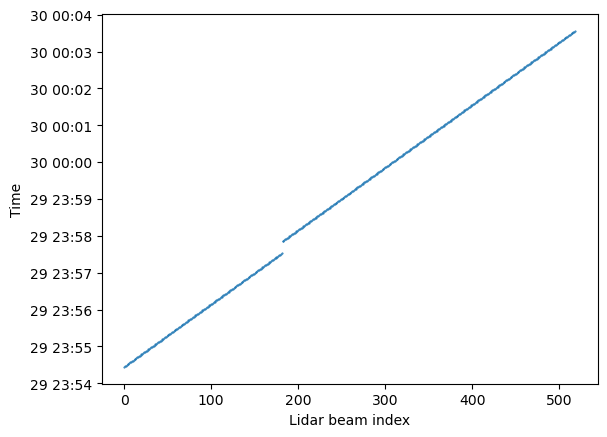

Python: Text(0.5, 24.0, 'Lidar beam index')

In [43]:
stride = 20*60
ii = findfirst(Vn[:vndt][:].>=DateTime("2024-04-29T23:50")):stride:findlast(Vn[:vndt][:].<=DateTime("2024-04-30T00:10"))
plot(Vn[:vndt][ii], Vn[:VelNED2][ii], marker=".", markersize=1, linestyle="none")
# there is Vn data
# now plot the lidar stare data
clf()
lstride = 10
state = LidarVNSync.init_stream_state()
all_times = []
for ic in 285:285
    win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic; ntop=nz, nc_dir="./data/netcdf_stare")
    append!(all_times, win.stare_dt)
end
all_times = collect(all_times)
plot(all_times[1:end], marker=".", markersize=1, linestyle="none")
ylabel("Time")
xlabel("Lidar beam index")
# gcf()


In [44]:
# typeof(win) # NamedTuple with fields:
# ifile: 	 Int64
# ist: 	 Int64
# ien: 	 Int64
# stare_dt_raw: 	 543-element Vector{DateTime}
# stare_dt: 	 543-element Vector{DateTime}
# lidar_clock_fast_by: 	 Millisecond
# dopplervel: 	 543×80 Matrix{Union{Missing, Float32}}
# intensity: 	 543×80 Matrix{Union{Missing, Float32}}
# beta: 	 543×80 Matrix{Union{Missing, Float32}}
# pitch: 	 543-element Vector{Float64}
# roll: 	 543-element Vector{Float64}
# vn0: 	 543-element Vector{Float64}
# vn1: 	 543-element Vector{Float64}
# vn2: 	 543-element Vector{Float64}
# vn2_xcorr: 	 543-element Vector{Float64}
# Ur: 	 543×80 Matrix{Float64}
# Vr: 	 543×80 Matrix{Float64}
# mdv: 	 543-element Vector{Float32}
# mdv_builtin: 	 543-element Vector{Union{Missing, Float32}}
# goodlevels: 	 23-element Vector{Int64}
# vn_coverage: 	 Float64
# vn2_xcorr_nan_frac: 	 Float64

# all synced to lidar time base
# for (k, v) in pairs(win)
#     println("$k: \t $(summary(v))")
# end

# win.vn2_xcorr_nan_frac # no NaNs

In [45]:
# ── Verify midnight-crossing fix ────────────────────────────────────────────
# Revise should have auto-reloaded lidar_vn_sync.jl.  Force it if needed.
Revise.revise()

state_fix = LidarVNSync.init_stream_state()
println("── Chunk times after midnight-crossing fix ─────────────────────────────────")
@printf("  %-5s  %-5s  %-28s  %-28s  %-10s  %-10s\n",
    "chunk", "ifile", "stare_dt[1]", "stare_dt[end]", "vn_cov", "n_vn_pts")
println("  " * "─"^80)
for ic in [283, 284, 285, 286, 287]
    win = LidarVNSync.extract_sync_window(beams, Env, state_fix, Vn, UV, ic;
              ntop=nz, nc_dir="./data/netcdf_stare")
    _, vndt_c, _ = LidarVNSync.vn_subset_20hz(win.stare_dt, Vn; pad=Second(0))
    @printf("  %-5d  %-5d  %-28s  %-28s  %-10.4f  %-10d\n",
        ic, win.ifile,
        string(win.stare_dt[1]),
        string(win.stare_dt[end]),
        win.vn_coverage,
        length(vndt_c))
end


── Chunk times after midnight-crossing fix ─────────────────────────────────
  chunk  ifile  stare_dt[1]                   stare_dt[end]                 vn_cov      n_vn_pts  
  ────────────────────────────────────────────────────────────────────────────────
  283    48     2024-04-29T23:34:25.883       2024-04-29T23:43:32.651       0.9934      10863     
  284    48     2024-04-29T23:44:26.250       2024-04-29T23:53:32.994       0.9939      10868     
  285    48     2024-04-29T23:54:26.697       2024-04-30T00:03:33.701       0.9938      10872     
  286    49     2024-04-30T00:04:27.306       2024-04-30T00:13:34.006       0.9936      10864     
  287    49     2024-04-30T00:14:27.611       2024-04-30T00:23:34.271       0.9932      10859     


In [46]:
# Diagnostic: Print gating variables for chunk 285
state = LidarVNSync.init_stream_state()
ic = 285
win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic; ntop=nz, nc_dir="./data/netcdf_stare")

# VN coverage and NaN fraction in vn2_xcorr
vn_coverage = win.vn_coverage
vn2_xcorr_nan_frac = mean(isnan.(win.vn2_xcorr))
n_finite_vn2 = count(isfinite, win.vn2_xcorr)
n_total_vn2 = length(win.vn2_xcorr)

# Lidar and VN time ranges
lidar_t0 = isempty(win.stare_dt) ? missing : win.stare_dt[1]
lidar_t1 = isempty(win.stare_dt) ? missing : win.stare_dt[end]
_, vndt_c, _ = LidarVNSync.vn_subset_20hz(win.stare_dt, Vn; pad=Second(0))
vn_t0 = isempty(vndt_c) ? missing : vndt_c[1]
vn_t1 = isempty(vndt_c) ? missing : vndt_c[end]
n_vn_pts = length(vndt_c)

println("--- Chunk 285 Sync Diagnostics ---")
println("VN coverage:         ", vn_coverage)
println("vn2_xcorr NaN frac:  ", vn2_xcorr_nan_frac)
println("vn2_xcorr n_finite:  ", n_finite_vn2, " / ", n_total_vn2)
println("Lidar time range:    ", lidar_t0, " to ", lidar_t1)
println("VN time range:       ", vn_t0, " to ", vn_t1, " (", n_vn_pts, " pts)")

# Print gating logic
if vn_coverage < 0.5
    println("SYNC SKIPPED: VN coverage below threshold (", vn_coverage, " < 0.5)")
elseif vn2_xcorr_nan_frac > 0.15
    println("SYNC SKIPPED: vn2_xcorr NaN fraction above threshold (", vn2_xcorr_nan_frac, " > 0.15)")
elseif n_finite_vn2 == 0
    println("SYNC SKIPPED: No finite VN2 data in window")
else
    println("SYNC SHOULD PROCEED: All gating conditions passed")
end


--- Chunk 285 Sync Diagnostics ---
VN coverage:         0.993777010771402
vn2_xcorr NaN frac:  0.0
vn2_xcorr n_finite:  519 / 519
Lidar time range:    2024-04-29T23:54:26.697 to 2024-04-30T00:03:33.701
VN time range:       2024-04-29T23:54:26.733 to 2024-04-30T00:03:33.688 (10872 pts)
SYNC SHOULD PROCEED: All gating conditions passed


In [47]:
#= commented out - plot vn mdt data from window of chunk 285
# state = LidarVNSync.init_stream_state()
ic = 285
win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic; ntop=nz, nc_dir="./data/netcdf_stare")
clf()
subplot(2,1,1)

plot(win.stare_dt, win.mdv, marker=".", markersize=1, linewidth=0.4)
xlabel("Time")
stride=20
iv = findfirst(Vn[:vndt][:] .>= win.stare_dt[1]) : stride : findlast(Vn[:vndt][:] .<= win.stare_dt[end])
plot(Vn[:vndt][iv], Vn[:VelNED2][iv], marker=".", markersize=1, linewidth=0.4)
# gcf()
=#

In [17]:
# Step-by-step sync calculation for chunk 285
state = LidarVNSync.init_stream_state()
ic = 285
win = LidarVNSync.extract_sync_window(beams, Env, state, Vn, UV, ic; ntop=nz, nc_dir="./data/netcdf_stare")

println("Lidar time range:    ", isempty(win.stare_dt) ? missing : (win.stare_dt[1], win.stare_dt[end]))
println("VN time range:       ", begin _, vndt_c, _ = LidarVNSync.vn_subset_20hz(win.stare_dt, Vn; pad=Second(0)); isempty(vndt_c) ? missing : (vndt_c[1], vndt_c[end]) end)

# Visualize lidar time gaps
diffs = diff(Float64.(Dates.datetime2epochms.(win.stare_dt))) ./ 1000.0

# clf()
# subplot(2,1,1)
# plot(diffs, marker=".", linestyle="none")
# xlabel("Lidar beam index")
# ylabel("Time gap (s)")
# title("Lidar beam-to-beam time gaps (chunk 285)")
# sum(diffs .> 2.0)  # count gaps > 2 s
# gcf()
igaps = findall(diffs .> 2.0)
# println("Lidar gaps > 2 s at beam indices: ", igaps)

Lidar time range:    (DateTime("2024-04-29T23:54:26.697"), DateTime("2024-04-30T00:03:33.701"))
VN time range:       (DateTime("2024-04-29T23:54:26.733"), DateTime("2024-04-30T00:03:33.688"))


1-element Vector{Int64}:
 182

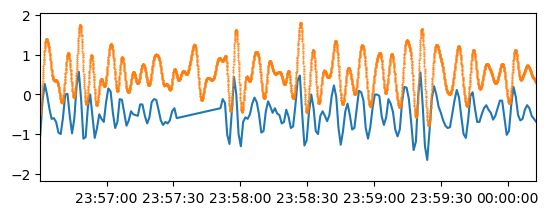

Python: (np.float64(19842.997571956017), np.float64(19843.000148159725))

In [18]:
# Step 1: Coarse and fine lag
igap = igaps[1]
prior_s = -0.0  # or use prior if available
s = LidarVNSync.coarse_and_fine_lag(win.mdv, win.vn2_xcorr; prior_seconds=0.0)

#= Plot unrefined signals from win
si=2
subplot(2,1,si)
plot(win.stare_dt[:], win.mdv[:] .- 0.5, label="mdv")
# Vn[:vndt][findfirst(Vn[:vndt][:] .>= win.stare_dt[1]) : findlast(Vn[:vndt][:] .<= win.stare_dt[end])]
iv = findfirst(Vn[:vndt][:] .>= win.stare_dt[1]) : findlast(Vn[:vndt][:] .<= win.stare_dt[end])
iv2 = findfirst(Vn[:vndt][:] .>= win.stare_dt[igap]) : findlast(Vn[:vndt][:] .<= win.stare_dt[end])
plot(Vn[:vndt][iv], Vn[:VelNED2][iv] .+ 0.5, marker=".", markersize=1, linewidth=0.2, label="vn2_20hz")
# plot(1.02*(0:length(i[si])-1) .+ 25, win.vn2_xcorr[i[si]] .+ 0.5, label="vn2_aligned", linewidth=0.5)
# plot(-0 .+(1:length(i[si])), win.vn2_xcorr[i[si]], label="vn2_xcorr", linewidth=0.5)
# legend()
xlim([win.stare_dt[igap-60], win.stare_dt[igap+140]])
=#

[ Info: Final offset (s): -0.8200000000000001
[ Info: Correlation after alignment: 0.9576266731582309


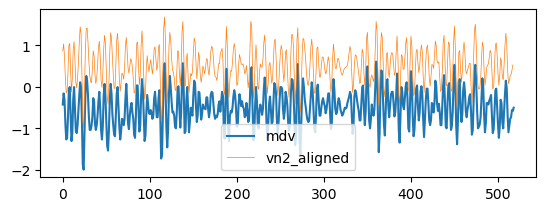

Python: <matplotlib.legend.Legend object at 0x3d71d4ec0>

In [ ]:
# @info "Coarse+fine lag result: $(seg[1])"

# loop over segments (before and after gap)
# clf()

    # Step 2: 20 Hz refinement
    rf = LidarVNSync.refine_offset_20hz(win, s, Vn)
    # @info "20 Hz refinement result: $(rf)"

    # Step 3: Compose final offset
    final_offset = s.final_offset + rf.final_offset_native
    @info "Final offset (s): $(final_offset)"

    # Step 4: Correlation after alignment
    vn2_aligned = LidarVNSync.shift_signal_linear(win.vn2_xcorr, final_offset; dt=LidarVNSync.dt_seconds(win.stare_dt))
    corr_aligned = pearson_finite(win.mdv, vn2_aligned)
    @info "Correlation after alignment: $(corr_aligned)"

    # Step 5: Plot aligned signals (first 200 points)
    subplot(2,1,si)
    plot(win.mdv .- 0.5, label="mdv")
    plot(vn2_aligned .+ 0.5, label="vn2_aligned", linewidth=0.5)
    # plot(-0 .+(1:length(i[si])), win.vn2_xcorr[i[si]], label="vn2_xcorr", linewidth=0.5)
    legend()

# gcf()


Loop over all chunks. Compute vn2_aligned. Save vn2_aligned in Stare .nc file

In [32]:
# test: first day's chunks only
# Env.dtime[Env.ists[icvn[1:10]]]
# icvn starts indexing chunks on 2024-04-29
sync_chunk_path = "data/vn_sync_chunk_daily"
# icvn indexes chunks filtered to be covered by VN data
ic_day1 = filter(ic -> Date(Env.dtime[Env.ists[ic]]) == Date(2024, 4, 29), collect(icvn))
LidarVNSync.write_daily_mdv_vn2!(; out_dir=sync_chunk_path, ic_list=ic_day1, overwrite=false)
# LidarVNSync.write_daily_mdv_vn2!(; out_dir=sync_chunk_path, ic_list=ic_day1, overwrite=true)

write_daily_mdv_vn2!: 111 chunks → data/vn_sync_chunk_daily
  Log: epsilon_data/daily_mdv_vn2_20260502_112402.log
Phase 1: 1 Hz sequential offsets …


LoadError: InterruptException:

I ran write_daily_mdv_vn2! selecting ic_list=ic_day1 (for 4-28) but it still processes all the data.

Since it takes more than an hour to run, it should output daily data files as it goes, rather than waiting until the end to write.

In [ ]:
# now do all chunks (takes > 1 hour)
LidarVNSync.write_daily_mdv_vn2!(; out_dir=sync_chunk_path, overwrite=false)